# 4장. 딥러닝 시작

## 4.1 인공 신경망의 한계와 딥러닝 출현

#### AND 게이트
AND 게이트는 모든 입력이 '1'일 때 작동함. 입력 중 어떤 하나라도 0을 갖는다면 작동을 멈춘다.

#### OR 게이트
OR 게이트는 입력에서 둘 중 하나만 1이거나 둘 다 1일 때 작동함. 입력 모두가 0을 갖는 경우를 제외한 나머지가 모두 1 값을 갖는다.

#### XOR 게이트
XOR 게이트는 배타적 논리합이라는 용어로 입력 두 개 중 한 개만 1일 때 작동하는 논리 연산이다. 이 게이트는 데이터가 비선형적으로 분리되기 때문에 제대로 된 분류가 어렵다. 즉, 단층 퍼셉트론에서는 AND, OR 연산에 대해서는 학습이 가능하지만, XOR에 대해서는 학습이 불가능하다.

이를 해결하는 방법은 입력층과 출력층 사이에 하나 이상의 은닉층을 두어 비선형적으로 분리되는 데이터에 대해서도 학습이 가능하도록 다층 퍼셉트론을 고안했다.

입력층과 출력층 사이에 은닉층이 여러 개 있는 신경망을 심층 신경망(Deep Neural Network)이라고 하며, 딥러닝이라고 함.

## 4.2 딥러닝 구조

### 4.2.1 딥러닝 용어


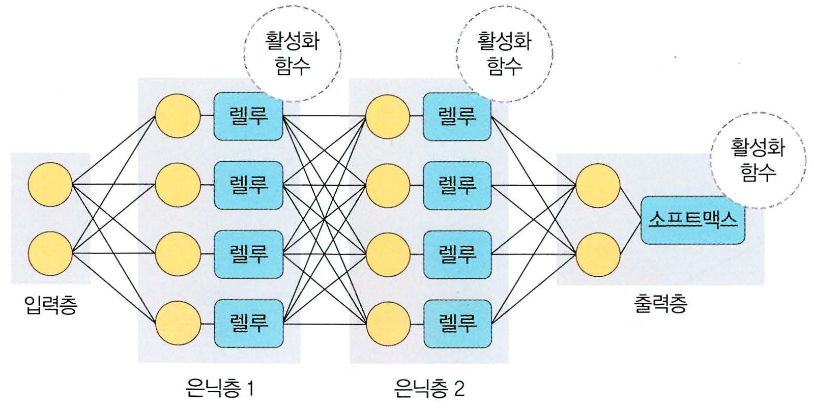

[딥러닝 구성 요소]
- 층
  - 입력층
  - 은닉층
  - 출력층
- 가중치
- 바이어스
- 가중합, 전달 함수
- 함수
  - 활성화 함수: 신호를 입력받아 이를 적절히 처리하여 출력해 주는 함수
  - 손실 함수: 가중치 학습을 위해 출력 함수의 결과와 실제 값 간의 오차를 측정하는 함수

#### 가중치
입력 값이 연산 결과에 미치는 영향력을 조절하는 요소다.

#### 가중합 또는 전달 함수
가중합은 전달 함수라고 한다. 각 노드에서 들어오는 신호에 가중치를 곱해서 다음 노드로 전달되는데, 이 값들을 모두 더한 합계를 가중합이라고 한다. 또한 노드의 가중합이 계산되면 이 가중합을 활성화 함수로 보내기 때문에 전달 함수라고 한다.

[공식]

$sum(wi*xi) + b$

#### 활성화 함수
전달 함수에서 전달받은 값을 출력할 때 일정 기준에 따라 출력 값을 변화시키는 비선형 함수다.

1. 시그모이드 함수

선형 함수의 결과를 0~1 사이에서 비선형 형태로 변형해 준다. 주로 로지스틱 회귀와 같은 분류 문제를 확률적으로 표현하는 데 사용된다. 하지만 모델의 깊이가 깊어지면 기울기가 사라지는 기울기 소멸 문제가 발생한다.

$f(x) = 1/(1+e^-x)$

2. 하이퍼볼릭 탄젠트 함수

선형 함수의 결과를 -1~1 사이에서 비선형 형태로 변형해 준다. 시그모이드에서 결괏값의 평균이 0이 아닌 양수로 편향된 문제를 해결하는 데 사용했지만, 기울기 소멸 문제가 있음

3. ReLU

입력이 음수일 때는 0을 출력하고 양수일 때는 x를 출력한다. 경사 하강법에 영향을 주지 않아 학습 속도가 빠르고, 기울기 소멸 문제가 발생하지 않는 장점이 있다. 렐루 함수는 은닉층에서 사용되고 학습 속도가 빠르다. 문제는 음수값을 입력받으면 항상 0을 출력해서 학습 능력이 감소한다는 것이고, 리키 렐루 함수를 사용하면 된다.

4. Leaky ReLU

입력 값이 음수이면 0이 아닌 0.001처럼 매우 작은 수를 반환한다. 입력 값이 수렴하는 구간이 제거되어 렐루 함수 문제 해결할 수 있다.

5. Softmax

입력 값을 0~1 사이에 출력되도록 정규화하여 출력 값들의 총합이 항상 1이 되도록 한다. 이 함수는 출력 노드의 활성화 함수로 많이 사용된다.

$y = exp(ak)/sum(exp(ai))$

In [2]:
import torch
import torch.nn as nn

class Net(torch.nn.Module):
  def __init__(self, n_feature, n_hidden, n_output):
    super(Net, self).__init__()
    self.hidden = torch.nn.Linear(n_feature, n_hidden)
    self.relu = torch.nn.ReLu(inplace = True)
    self.out = torch.nn.Linear(n_hidden, n_output)
    self.softmax = torch.nn.Softmax(dim = n_output)
  def forward(self, x):
    x = self.hidden(x)
    x = self.relu(x)
    x = self.out(x)
    x = self.softmax(x)
    return x

#### 손실 함수

- 경사 하강법: 학습률과 손실 함수의 순간 기울기를 이용하여 가중치를 업데이트하는 방법이다. 즉, 미분의 기울기를 이용하여 오차를 비교하고 최소화하는 방향으로 이동시키는 방법이다. 이때 오차를 구하는 방법이 손실 함수다.

1. 평균 제곱 오차: 실제 값과 예측 값의 차이를 제곱하여 평균을 낸 것. 작을수록 좋음.

In [ ]:
import torch

loss_fn = torch.nn.MSELoss(reduction='sum')
y_pred = model(x)
loss = loss_fn(y_pred, y)

2. 크로스 엔트로피 오차: 분류 문제에서 원-핫 인코딩을 했을 때 사용할 수 있는 오차 계산법. 이는 두 개의 확률 분포 차이를 이용하기 때문에 시그모이드의 영향을 덜 받음. 학습 속도가 빠름.

In [ ]:
loss = nn.CrossEntropyLoss()
input = torch.randn(5, 6, requires_grad=True)
target = torch.empty(3, dtype=torch.long).random_(5)
output = loss(input, target)
output.backward()

### 4.2.2 딥러닝 학습

1. 순전파(feedforward)
- 네트워크에 훈련 데이터가 들어올 때 발생
- 데이터를 기반으로 예측 값을 계산하기 위해 전체 신경망을 교차해 지나감
- 즉, 모든 뉴런이 이전 층의 뉴런에서 수신한 정보에 변환을 적용하여 다음 층의 뉴런으로 전송하는 방식
- 네트워크를 통해 입력 데이터를 전달 -> 데이터가 모든 층을 통과하고 모든 뉴런이 계산 완료 -> 예측 값은 출력층 도달 -> 손실 함수로 오차 추정

2. 역전파(backpropagation)
- 손실 함수 비용이 0에 가깝도록 하기 위해 모델이 훈련 반복하면서 가중치를 조정 -> 역으로 전파
- 뉴런이 원래 출력에 기여한 상대적 기여도에 따라 값이 달라짐

### 4.2.3 딥러닝의 문제점과 해결 방안

[딥러닝 핵심]

활성화 함수가 적용된 여러 은닉층을 결합하여 비선형 영역을 표현하는 것이다. 은닉층 개수가 많을수록 데이터 분류가 잘되지만 세 가지 문제점이 있다.

1. 과적합 문제 발생

훈련 데이터를 과하게 학습해서 발생. 훈련 데이터에 대해 과하게 학습하여 실제 데이터에 대한 오차가 증가하는 현상이다.

- 해결 방법: 드롭아웃(dropout)
  - 학습 과정 중 임의로 일부 노드들을 학습에서 제외

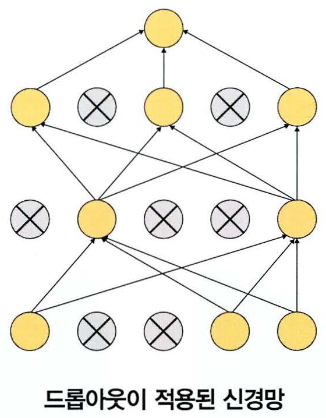

In [ ]:
class DropoutModel(torch.nn.Module):
  def __init__(self):
    super(DropoutModel, self).__init__()
    self.layer1 = torch.nn.Linear(784, 1200)
    self.dropout1 = torch.nn.Dropout(0.5) # 50%의 노드를 무작위로 선택하여 사용하지 않겠다는 의미
    self.layer2 = torch.nn.Linear(1200, 1200)
    self.dropout2 = torch.nn.Dropout(0.5)
    self.layer3 = torch.nn.Linear(1200, 10)

  def forward(self, x):
    x = F.relu(self.layer1(x))
    x = self.dropout1(x)
    x = F.relu(self.layer2(x))
    x = self.dropout2(x)
    return self.layer3(x)

2. 기울기 소멸 문제 발생

은닉층이 많은 신경망에서 주로 발생. 출력층에서 은닉층으로 전달되는 오차가 크게 줄어들어 학습이 되지 않는 현상이다. 즉, 기울기가 소멸되기 때문에 학습되는 양이 0에 가까워져 학습이 더디게 진행, 오차 줄이지 못하고 그 상태로 수렴하는 현상

- 해결 방법: 렐루 활성화 함수 사용

3. 성능이 나빠지는 문제 발생

경사 하강법은 손실 함수의 비용이 최소가 되는 지점을 찾을 때까지 기울기가 낮은 쪽으로 계속 이동시키는 과정 반복하는데, 이때 성능이 나빠지는 문제 발생.

- 해결 방법: 확률적 경사 하강법, 미니 배치 경사 하강법 사용

#### 배치 경사 하강법(Batch Gradient Descent, BGD)
전체 데이터셋에 대한 오류를 구한 후 기울기를 한 번만 계산하여 모델의 파라미터를 업데이트하는 방법. 즉, 전체 훈련 데이터셋에 대해 가중치를 편미분하는 방법. 한 스텝에 모든 훈련 데이터셋을 사용하므로 학습이 오래걸림.

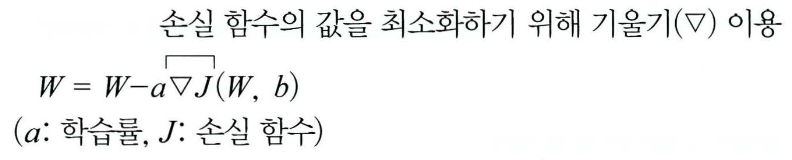

#### 확률적 경사 하강법(Stochastic Gradient Descent, SGD)
임의로 선택한 데이터에 대해 기울기를 계산하는 방법. 적은 데이터를 사용하므로 빠른 계산이 가능. 배치 경사 하강법보다 정확도가 낮을 수 있지만 속도가 빠르다.

#### 미니 배치 경사 하강법(mini-batch gradient descent)
전체 데이터셋을 미니 배치 여러 개로 나누고, 미니 배치 한 개마다 기울기를 구한 후 그것의 평균 기울기를 이용하여 모델을 업데이트해서 학습하는 방법. 전체 데이터를 계산하는 것보다 빠르며, ㅎ보다 안정적이면서 속도도 빠르다.

In [ ]:
class CustomDataset(Dataset):
  self.x_data = [[1,2,3], [4,5,6], [7,8,9]]
  self.y_data = [[12],[18],[11]]

  def __len__(self):
    return len(self.x_data)

  def __getitem__(self, idx):
    x = torch.FloatTensor(self.x_data[idx])
    y = torch.FloatTensor(self.y_data[idx])
    return x, y

dataset = CustomDataset()
dataloader = DataLoader(
    dataset,
    batch_size = 2,
    shuffle = True
)

#### 옵티마이저
확률적 경사 하강법의 파라미터 변경 폭이 불안정한 문제를 해결하기 위해 학습 속도와 운동량을 조절하는 옵티마이저를 적용해 볼 수 있다.

**[속도를 조정하는 방법]**
1. 아다그라드(Adagrad, Adaptive gradient)

변수의 업데이트 횟수에 따라 학습률을 조정하는 방법. 많이 변화하지 않는 변수들의 학습률은 크게 하고, 많이 변화하는 변수들의 학습률은 작게 한다. 즉, 많이 변화한 변수는 최적 값에 근접했을 것이라는 가정하에 작은 크기로 이동하면서 세밀하게 값을 조정하고, 반대로 적게 변화한 변수들은 학습률을 크게 하여 빠르게 오차 값을 줄이고자 하는 방법. 기울기가 0에 수렴하는 문제가 있음.

`optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)`

2. 아다델타(Adadelta, Adaptive delta)

아다그라드에서 G값이 커짐에 따라 학습이 멈추는 문제 해결하기 위해 등장. 이것은 아다그라드의 수식에서 학습률을 D 함수로 변환했기 때문에 학습률에 대한 하이퍼파라키터가 필요하지 않다.

`optimizer = torch.optim.Adadelta(model.parameters(), lr=1.0)`

3. 알엠에스프롭(RMSProp)

아다그라드의 G값이 무한히 커지는 것을 방지하고자 제안된 방법. 아다그라드에서 학습이 안 되는 문제를 해결하기 위해 G 함수에서 감마만 추가되었음. 즉, G값이 너무 크면 학습률이 작아져 학습이 안 될 수 있으므로 사용자가 감마 값을 이용하여 학습률 크기를 비율로 조정할 수 있도록 함.

`optimizer = torch.optim.RMSprop(model.parameters(), lr = 0.01)`

**[운동량을 조정하는 방법]**
1. 모멘텀(Momentum)

가중치를 수정하기 전에 이전 수정 방향을 참고하여 같은 방향으로 일정한 비율만 수정하는 방법이다. 지그재그 현상이 줄어들고 이전 이동 값을 고려하여 일정 비율만큼 다음 값을 결정하므로 관성 효과를 얻을 수 있는 장점이 있다. SGD와 함께 사용.

`optimizer = torch.optim.SGD(model.parameters(), lr = 0.01, momentum = 0.9)`

2. 네스테로프 모멘텀(Nesterov Accelerated Gradient, NAG)

모멘텀 값과 기울기 값이 더해져 실제 값을 만드는 기존 모멘텀과 달리 모멘텀 값이 적용된 지점에서 기울기 값 계산. 절반 정도 이동한 후 어떤 방식으로 이동해야 하는지 다시 계산하여 결정하기 때문에 모멘텀 방법의 단점을 극복할 수 있다. 모멘텀 방법의 이점인 빠른 이동 속도는 가져가면서 멈춰야 할 적절한 시점에서 제동거는 데 용이.

`optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)`

**[속도와 운동량에 대한 혼용 방법]**
1. 아담(Adam, Adaptive Moment Estimation)

모멘텀 + 알엠에스프롭. 알엠에스프롭 특징인 기울기의 제곱을 지수 평균한 값과 모멘텀 특징을 수식에 활용.

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

### 4.2.4 딥러닝을 사용할 때 이점

1. 특성 추출

데이터별로 어떤 특징을 갖고 있는지 찾아내고, 그것을 토대로 데이터를 벡터로 변환하는 작업. 머신러닝 알고리즘은 복잡하며 수집된 데이터에 대한 전문 지식이 필요.

2. 빅데이터의 효율적 활용

## 4.3 딥러닝 알고리즘

### 4.3.1 심층 신경망(DNN)
입력층과 출력층 사이에 다수의 은닉층을 포함하는 인공 신경망. 별도의 트릭 없이 비선형 분류가 가능함. 비선형적 관계를 학습할 수 있는 장점이 있지만, 학습을 위한 연산량이 많고 기울기 소멸 문제 등이 발생. 이를 위해 드롭아웃, 렐루 함수, 배치 정규화 적용.

### 4.3.2 합성곱 신경망(CNN, Convolution Neural Network)
합성곱층과 풀링층을 포함하는 이미지 처리 성능이 좋은 인공 신경망 알고리즘. 이미지 데이터에서 객체를 탐색하거나 객체 위치를 찾아내는 데 유용. 대표적인 합성곱 신경망으로 LeNet-5, AlexNet, VGGm GoogLeNet, ResNet이 있다.

- 각 층의 입출력 형상 유지
- 이미지의 공간 정보 유지하면서 인접 이미지와 차이가 있는 특징을 효과적으로 인식
- 복수 필터로 이미지의 특징을 추출하고 학습
- 추출한 이미지의 특징을 모으고 강화하는 풀링층 있음
- 필터를 공유 파라미터로 사용하기 때문에 일반 인공 신경망과 비교하여 학습 파라미터가 매우 적음

### 4.3.3 순환 신경망(Recurrent Neural Network)
시계열 데이터 같은 시간 흐름에 따라 변화하는 데이터를 학습하기 위한 인공 신경망. '순환'은 자기 자신을 참조한다는 것으로, 현재 결과가 이전 결과와 연관이 있다는 의미다.

[특징]
- 시간성을 가진 데이터가 많음
- 시간성 정보를 이용하여 데이터의 특징을 잘 다룸
- 시간에 따라 내용이 변하므로 데이터는 동적이고 길이가 가변적
- 매우 긴 데이터를 처리하는 연구가 활발히 진행

기울기 소멸 문제있음. 이를 위해 LSTM이 순환 신경망에서 사용.

### 4.3.4 제한된 볼츠만 머신
볼츠만 머신은 가시층과 은닉층으로 구성된 모델. 이 모델에서 가시층은 은닉층과만 연결되는데 이것이 제한된 볼츠만 머신.

- 차원 감소, 분류, 선형 회귀 머신, 협업 필터링, 특성 값 학습, 주제 모델링에 사용
- 기울기 소멸 문제 해결하기 위해 사전 학습 용도로 활용 가능
- 심층 신뢰 신경망의 요소로 활용

### 4.3.5 심층 신뢰 신경망
입력층과 은닉층으로 구성된 제한된 볼츠만 머신을 블록처럼 여러 층으로 쌓은 형태로 연결된 신경망. 즉, 사전 훈련된 제한된 볼츠만 머신을 층층이 쌓아 올린 구조로, 레이블이 없는 데이터에 대한 비지도 학습.

[학습 절차]
1. 가시층과 은닉층 1에 제한된 볼츠만 머신을 사전 훈련
2. 첫 번째 층 입력 데이터와 파라미터을 고정하여 두 번째 층 제한된 볼츠만 머신을 사전 훈련
3. 원하는 층 개수만큼 제한된 볼츠만 머신을 쌓아 올려 전체 DBN을 완성

[특징]
- 순차적으로 심층 신뢰 신경망을 학습시켜 가면서 계층적 구조 생성
- 비지도 학습으로 학습
- 위로 올라갈수록 추상적 특성 추출
- 학습된 가중치를 다층 퍼셉트론의 가중치 초깃값으로 사용